---

# ASSIGNMENT 6: PIE & DONUT CHARTS

---

>---
>
>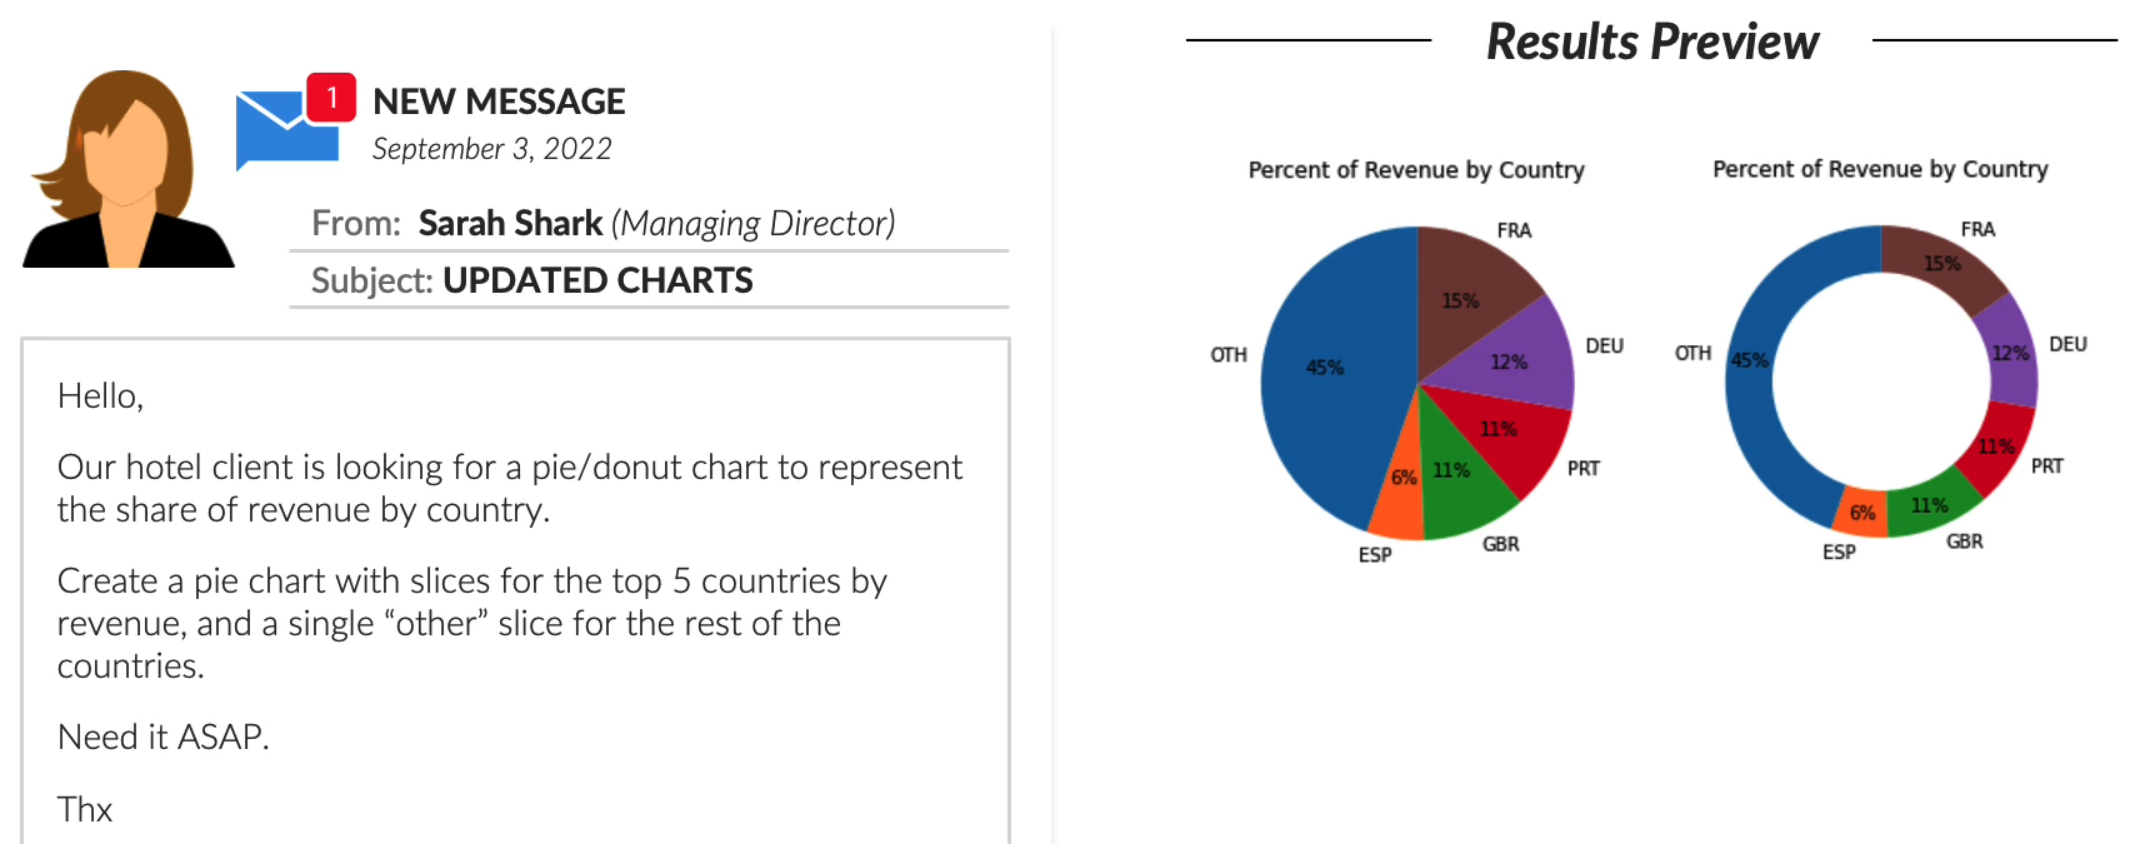
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('../Data/HotelCustomersDataset.xlsx')

df['date'] = (pd.to_datetime('2018-12-31') - pd.to_timedelta(df.DaysSinceCreation, unit='D')).astype('datetime64[ns]')
df = df[['Nationality', 'OtherRevenue', 'LodgingRevenue']]

display(df.head(), df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83590 entries, 0 to 83589
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Nationality     83590 non-null  object 
 1   OtherRevenue    83590 non-null  float64
 2   LodgingRevenue  83590 non-null  float64
dtypes: float64(2), object(1)
memory usage: 1.9+ MB


,Nationality,OtherRevenue,LodgingRevenue
0,PRT,105.3,371.0
1,PRT,53.0,280.0
2,DEU,0.0,0.0
3,FRA,60.0,240.0
4,FRA,0.0,0.0


None

In [3]:
top_five = list(df.groupby('Nationality').agg({'LodgingRevenue':'sum'}).sort_values(by='LodgingRevenue', ascending=False).head().index)
top_five

['FRA', 'DEU', 'PRT', 'GBR', 'ESP']

In [4]:
df['Country'] = df.Nationality.apply(lambda x: x if x in top_five else 'OTH')
df

,Nationality,OtherRevenue,LodgingRevenue,Country
0,PRT,105.3,371.0,PRT
1,PRT,53.0,280.0,PRT
2,DEU,0.0,0.0,DEU
3,FRA,60.0,240.0,FRA
4,FRA,0.0,0.0,FRA
...,...,...,...,...
83585,ITA,0.0,0.0,OTH
83586,IRL,277.5,327.1,OTH
83587,IRL,0.0,0.0,OTH
83588,IRL,9.0,981.3,OTH


In [5]:
df1 = df.groupby('Country').agg({'LodgingRevenue':'sum'}).sort_values(by='LodgingRevenue', ascending=False)
df1

,LodgingRevenue
Country,
OTH,11170126.66
FRA,3809315.59
DEU,3113382.55
PRT,2715008.72
GBR,2693123.61
ESP,1475909.33


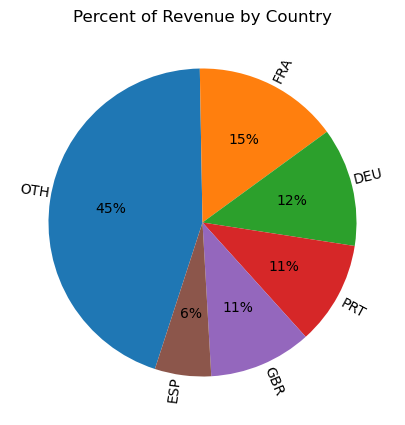

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.pie(df1.LodgingRevenue,
       labels=df1.index,
       startangle=252, # (360*45/100)=162+90=252
       counterclock=False,
       autopct='%.0f%%',
       rotatelabels=True,
       labeldistance=1)

ax.set_title('Percent of Revenue by Country')
plt.show()

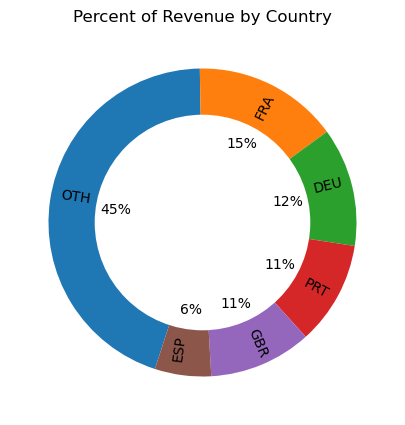

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.pie(x=df1.LodgingRevenue,
       labels=df1.index,
       startangle=-108, # -108 == 252
       counterclock=False,
       autopct='%.0f%%',
       pctdistance=0.57,
       labeldistance=0.73,
       rotatelabels=True,
       frame=False)

donut = plt.Circle((0,0), radius=0.7, facecolor='white')
ax.add_artist(donut)

ax.set_title('Percent of Revenue by Country')
plt.show()